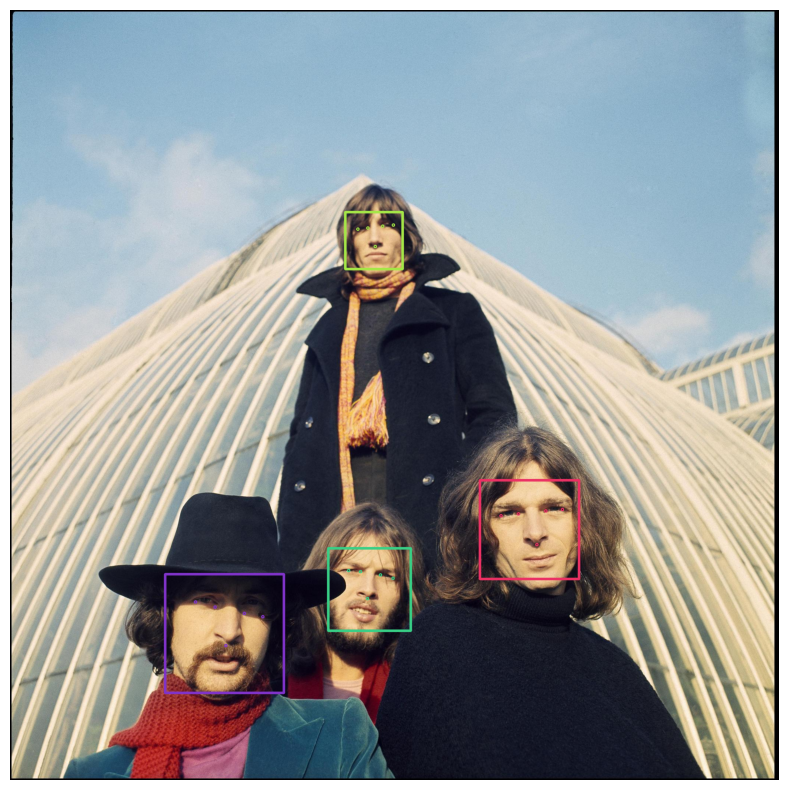

Number of faces detected: 4


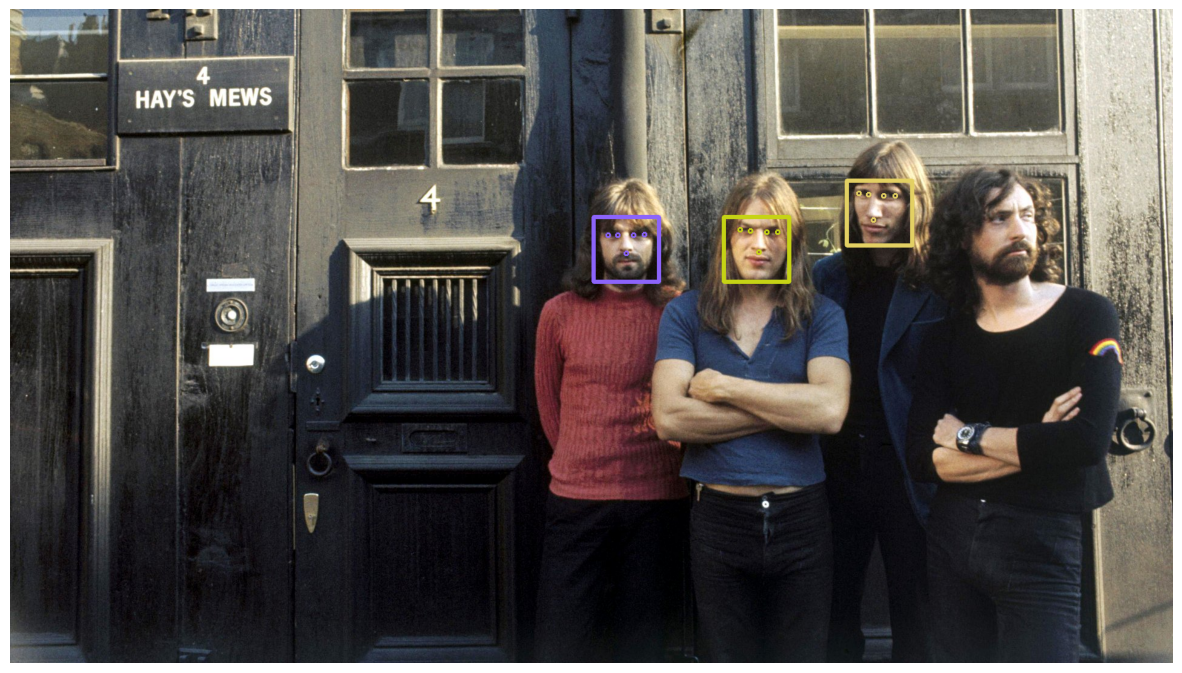

Number of faces detected: 3


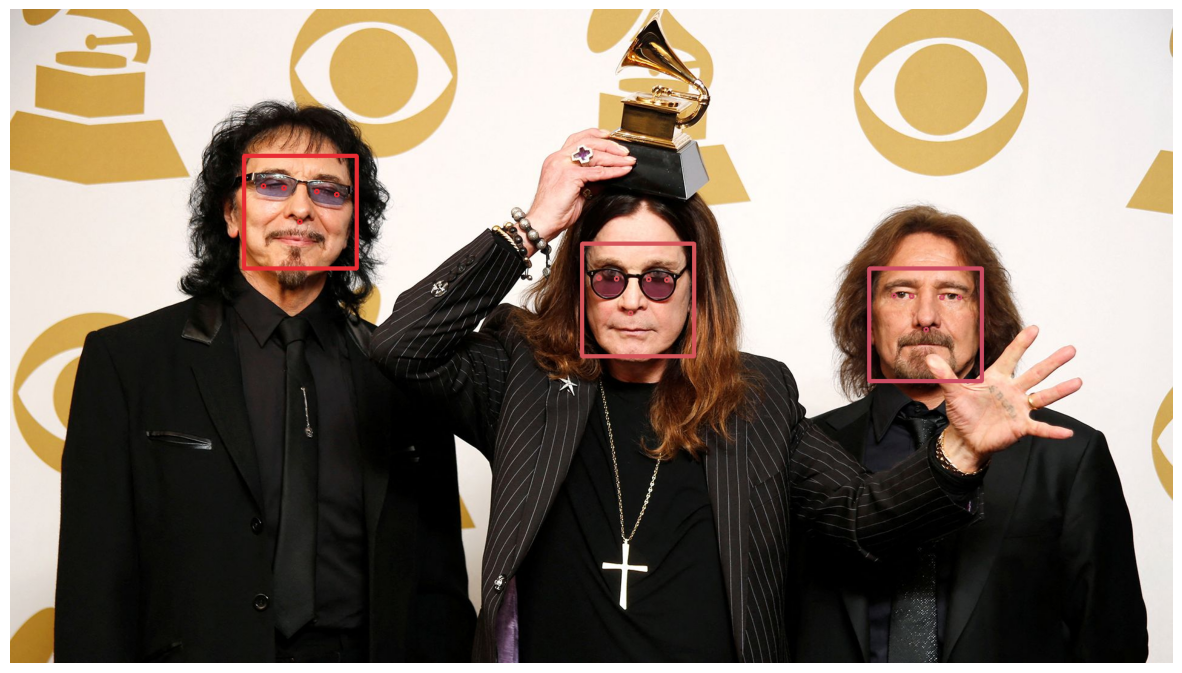

Number of faces detected: 3


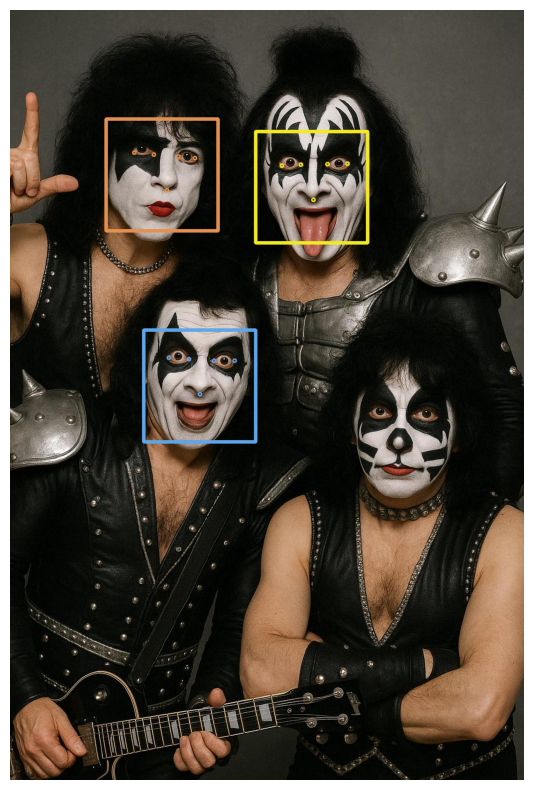

Number of faces detected: 3


In [ ]:
import cv2
import dlib
import random
import colorsys
from matplotlib import pyplot as plt

# Function to generate a random color in RGB format
def getRandomColor():
    h = random.random()                 # hue
    s = random.uniform(0.55, 0.9)       # saturation
    v = random.uniform(0.78, 1.0)       # brightness (not dark)

    # Convert HSV to RGB and scale to 0-255
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return tuple(int(c * 255) for c in (r, g, b))

plt.rcParams["figure.figsize"] = [15, 10]

def detectFacesOnImage(image_path):
  # Read the image
  img = cv2.imread(image_path)

  if img is None:
      print("Could not read the image.")
      raise Exception("Could not read the image.")

  # Convert the image to RGB and grayscale
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  # Initialize the face detector and shape predictor
  predictor = dlib.shape_predictor("../../data/lesson_9/shape_predictor_5_face_landmarks.dat")
  # Initialize the face detector
  detector = dlib.get_frontal_face_detector()
  faces = detector(img_gray, 1)

  # Loop through each detected face
  for i, face in enumerate(faces):
      # Get the landmarks for the face
      shape = predictor(img_gray, face)
      # Generate random color for current face
      face_color = getRandomColor()

      # Draw the landmarks on the image
      for i in range(shape.num_parts):
        x = shape.part(i).x
        y = shape.part(i).y
        cv2.circle(img, (x, y), 3, face_color, 2)

      # Draw a rectangle around the face
      cv2.rectangle(img, (face.left(), face.top()), (face.right(), face.bottom()), face_color, 5)

  # Display the image with detected faces and landmarks
  plt.imshow(img)
  plt.axis("off")
  plt.show()
  # Also print the number of faces detected
  print("Number of faces detected:", len(faces))

# List of images to process
images = [
    "../../data/lesson_9/Pink-Floyd.jpg",
    "../../data/lesson_9/Pink-Floyd2.jpg",
    "../../data/lesson_9/Ozzy-Osbourne.jpg",
    "../../data/lesson_9/Kiss.jpg",
]

# Detect faces on each image
for image_path in images:
    detectFacesOnImage(image_path)